# 05 - POS Tagging
Part-of-Speech (POS) Tagging on M-Tix reviews.

**POS Tagging** assigns grammatical categories (noun, verb, adjective, etc.) to each token.
This notebook uses NLTK's `pos_tag` function.

In [4]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\adhiraga\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\adhiraga\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adhiraga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\adhiraga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from collections import Counter
from nltk import pos_tag

## 1. Load Preprocessed Data

In [6]:
df = pd.read_csv('../data/preprocessed/mtix_preprocessed.csv')
df['clean_tokens'] = df['clean_tokens'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
print(f'Loaded {len(df)} rows')
df[['content', 'clean_tokens']].head()

Loaded 17311 rows


,content,clean_tokens
0,sangat memudahkan,"[sangat, memudahkan]"
1,seru,[seru]
2,oke,[oke]
3,lebih gampamg pesan,"[lebih, gampamg, pesan]"
4,alhamdulillah sdh diuinstall. aplikasi gk berg...,"[alhamdulillah, sdh, diuinstall, aplikasi, gk,..."


## 2. Apply POS Tagging

In [7]:
df['pos_tags'] = df['clean_tokens'].apply(pos_tag)
df[['content', 'clean_tokens', 'pos_tags']].head()

,content,clean_tokens,pos_tags
0,sangat memudahkan,"[sangat, memudahkan]","[(sangat, NN), (memudahkan, NN)]"
1,seru,[seru],"[(seru, NN)]"
2,oke,[oke],"[(oke, NN)]"
3,lebih gampamg pesan,"[lebih, gampamg, pesan]","[(lebih, NN), (gampamg, NN), (pesan, NN)]"
4,alhamdulillah sdh diuinstall. aplikasi gk berg...,"[alhamdulillah, sdh, diuinstall, aplikasi, gk,...","[(alhamdulillah, NN), (sdh, NN), (diuinstall, ..."


## 3. POS Tag Distribution

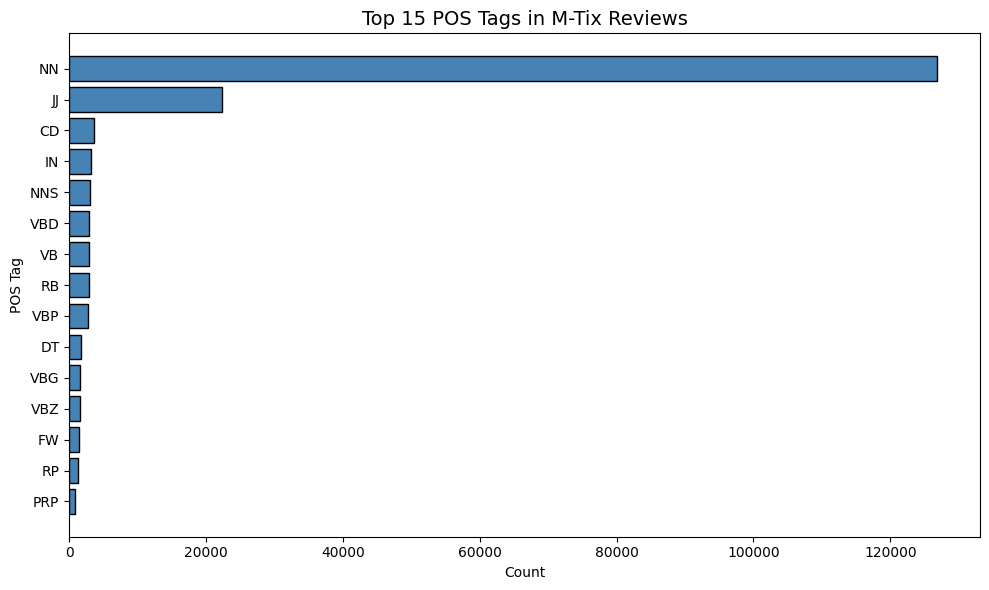

In [8]:
all_tags = [tag for tags in df['pos_tags'] for _, tag in tags]
tag_counts = Counter(all_tags).most_common(15)

tags = [t[0] for t in tag_counts]
counts = [t[1] for t in tag_counts]

plt.figure(figsize=(10, 6))
plt.barh(tags[::-1], counts[::-1], color='steelblue', edgecolor='black')
plt.title('Top 15 POS Tags in M-Tix Reviews', fontsize=14)
plt.xlabel('Count')
plt.ylabel('POS Tag')
plt.tight_layout()
plt.show()

## 4. Sample POS Tagged Reviews

In [9]:
for i, row in df.head(5).iterrows():
    print(f"Review: {row['content'][:80]}...")
    print(f"POS Tags: {row['pos_tags']}\n")

Review: sangat memudahkan...
POS Tags: [('sangat', 'NN'), ('memudahkan', 'NN')]

Review: seru...
POS Tags: [('seru', 'NN')]

Review: oke...
POS Tags: [('oke', 'NN')]

Review: lebih gampamg pesan...
POS Tags: [('lebih', 'NN'), ('gampamg', 'NN'), ('pesan', 'NN')]

Review: alhamdulillah sdh diuinstall. aplikasi gk berguna klo iklan ada gambarnya. film ...
POS Tags: [('alhamdulillah', 'NN'), ('sdh', 'NN'), ('diuinstall', 'NN'), ('aplikasi', 'NN'), ('gk', 'NN'), ('berguna', 'NN'), ('klo', 'NN'), ('iklan', 'NN'), ('ada', 'VBP'), ('gambarnya', 'NN'), ('film', 'NN'), ('cuma', 'NN'), ('item', 'NN'), ('doang', 'VBD'), ('gk', 'JJ'), ('ada', 'NN'), ('gbarnya', 'NN')]

